# Mental Health Risk Model Training

**Novelle — AI-Powered Maternal Health Risk Support Platform**

This notebook trains the mental health risk prediction model using XGBoost.

## Model Overview
- **Target**: Mental health risk level (LOW / MEDIUM / HIGH)
- **Input Features**: PHQ-9, GAD-7, mood, stress, social support scores
- **Algorithm**: XGBoost Classifier with hyperparameter tuning
- **Explainability**: SHAP values for feature importance

---

In [1]:
# Install dependencies (run once)
# !pip install pandas numpy scikit-learn xgboost lightgbm shap imbalanced-learn matplotlib seaborn joblib

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, roc_auc_score, precision_score, recall_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import joblib

print("✅ Libraries loaded successfully")
print(f"   XGBoost version: {xgb.__version__}")

/tmp/ipykernel_57148/3507143000.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Libraries loaded successfully
   XGBoost version: 2.0.3


## 2. Load Data

In [3]:
# Paths
DATA_DIR = Path('../datasets')
MODEL_DIR = Path('../../backend/app/ml/models')
REPORT_DIR = Path('../reports')

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Load datasets
mental_df = pd.read_csv(DATA_DIR / 'synthetic_mental_health.csv')
profiles_df = pd.read_csv(DATA_DIR / 'synthetic_profiles.csv')

print(f"Mental health records: {len(mental_df):,}")
print(f"User profiles: {len(profiles_df):,}")
print(f"Columns: {list(mental_df.columns)}")
mental_df.head()

Mental health records: 1,000
User profiles: 3,000
Columns: ['user_id', 'phq9_score', 'gad7_score', 'mood_score', 'stress_level', 'social_support_score', 'risk_label']


,user_id,phq9_score,gad7_score,mood_score,stress_level,social_support_score,risk_label
0,861,7,4,10,3,4,LOW
1,467,7,4,9,4,5,LOW
2,1686,7,3,7,4,3,LOW
3,1185,5,4,9,1,3,LOW
4,475,10,9,6,7,2,MEDIUM


## 3. Exploratory Data Analysis

In [4]:
# Dataset info
print("=" * 50)
print("MENTAL HEALTH DATASET INFO")
print("=" * 50)
print(mental_df.info())
print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
mental_df.describe()

MENTAL HEALTH DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   user_id               1000 non-null   int64 
 1   phq9_score            1000 non-null   int64 
 2   gad7_score            1000 non-null   int64 
 3   mood_score            1000 non-null   int64 
 4   stress_level          1000 non-null   int64 
 5   social_support_score  1000 non-null   int64 
 6   risk_label            1000 non-null   object
dtypes: int64(6), object(1)
memory usage: 54.8+ KB
None

STATISTICAL SUMMARY


,user_id,phq9_score,gad7_score,mood_score,stress_level,social_support_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1478.702000,11.281000,8.565000,5.708000,4.985000,3.121000
std,868.240464,7.003648,5.538633,2.477675,2.508599,1.153121
min,4.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,715.750000,6.000000,4.000000,4.000000,3.000000,2.000000
50%,1489.500000,10.000000,8.000000,6.000000,5.000000,3.000000
75%,2217.500000,16.000000,12.000000,7.000000,7.000000,4.000000
max,2994.000000,27.000000,21.000000,10.000000,10.000000,5.000000


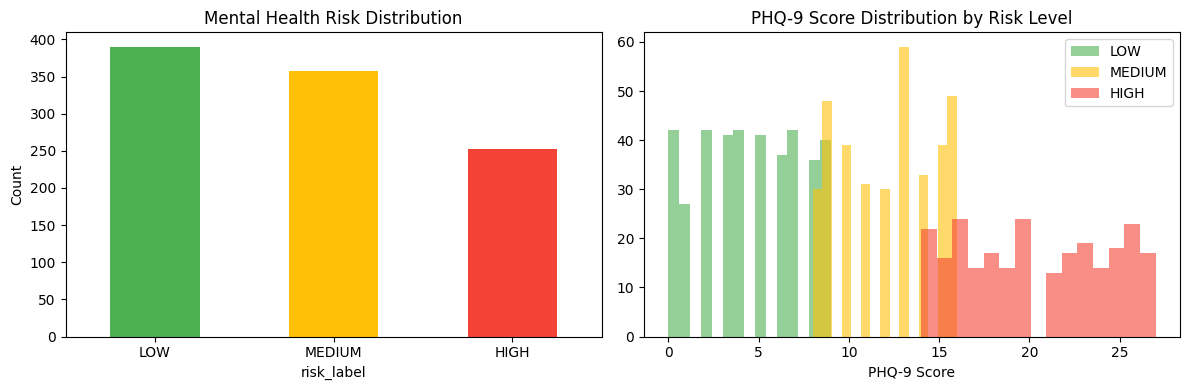

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Risk label distribution
risk_counts = mental_df['risk_label'].value_counts()
colors = {'LOW': '#4CAF50', 'MEDIUM': '#FFC107', 'HIGH': '#F44336'}
risk_counts.plot(kind='bar', ax=axes[0], color=[colors.get(x, '#666') for x in risk_counts.index])
axes[0].set_title('Mental Health Risk Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# PHQ-9 distribution by risk
for label in ['LOW', 'MEDIUM', 'HIGH']:
    subset = mental_df[mental_df['risk_label'] == label]
    axes[1].hist(subset['phq9_score'], alpha=0.6, label=label, color=colors[label], bins=15)
axes[1].set_title('PHQ-9 Score Distribution by Risk Level')
axes[1].set_xlabel('PHQ-9 Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / 'mental_health_eda.png', dpi=150)
plt.show()

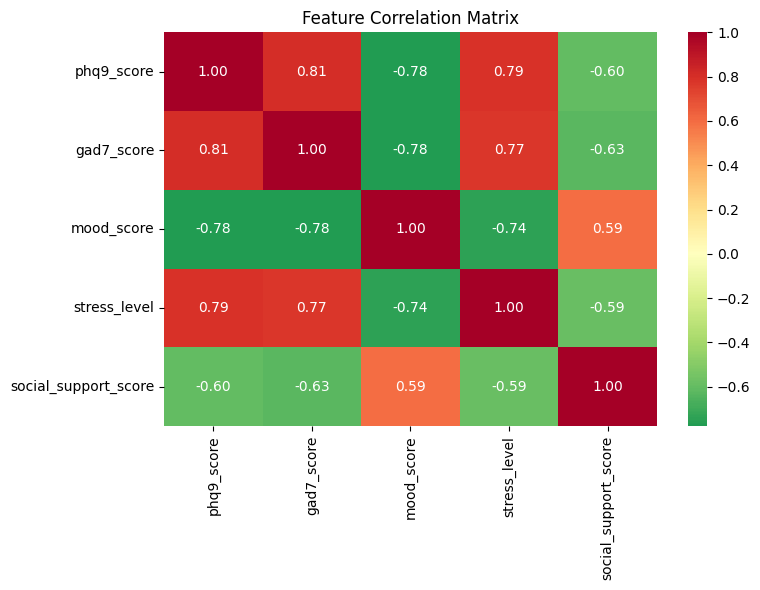

In [6]:
# Feature correlation heatmap
numeric_cols = ['phq9_score', 'gad7_score', 'mood_score', 'stress_level', 'social_support_score']
plt.figure(figsize=(8, 6))
sns.heatmap(mental_df[numeric_cols].corr(), annot=True, cmap='RdYlGn_r', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'mental_health_correlation.png', dpi=150)
plt.show()

## 4. Feature Engineering

In [7]:
# Merge with profile data for additional features
df = mental_df.merge(profiles_df[['user_id', 'age', 'pregnancy_week', 'trimester', 'previous_pregnancies']], 
                     on='user_id', how='left')

# Feature engineering
df['phq9_gad7_combined'] = df['phq9_score'] + df['gad7_score']  # Combined anxiety-depression score
df['mood_stress_ratio'] = df['mood_score'] / (df['stress_level'] + 1)  # Mood-stress balance
df['support_deficit'] = 5 - df['social_support_score']  # Inverse of support (higher = worse)
df['depression_severity'] = pd.cut(df['phq9_score'], bins=[0, 4, 9, 14, 19, 27], 
                                   labels=[0, 1, 2, 3, 4]).astype(float)  # PHQ-9 clinical severity
df['anxiety_severity'] = pd.cut(df['gad7_score'], bins=[0, 4, 9, 14, 21],
                                labels=[0, 1, 2, 3]).astype(float)  # GAD-7 clinical severity

# Encode trimester
trimester_map = {'first': 1, 'second': 2, 'third': 3}
df['trimester_num'] = df['trimester'].map(trimester_map).fillna(2)

print(f"Engineered features added. Total features: {len(df.columns)}")
df.head()

Engineered features added. Total features: 17


,user_id,phq9_score,gad7_score,mood_score,stress_level,social_support_score,risk_label,age,pregnancy_week,trimester,previous_pregnancies,phq9_gad7_combined,mood_stress_ratio,support_deficit,depression_severity,anxiety_severity,trimester_num
0,861,7,4,10,3,4,LOW,39,39,third,2,11,2.50,1,1.0,0.0,3
1,467,7,4,9,4,5,LOW,32,10,first,0,11,1.80,0,1.0,0.0,1
2,1686,7,3,7,4,3,LOW,35,3,first,2,10,1.40,2,1.0,0.0,1
3,1185,5,4,9,1,3,LOW,34,17,second,2,9,4.50,2,1.0,0.0,2
4,475,10,9,6,7,2,MEDIUM,40,27,second,4,19,0.75,3,2.0,1.0,2


## 5. Prepare Training Data

In [8]:
# Define features
FEATURE_COLS = [
    'phq9_score', 'gad7_score', 'mood_score', 'stress_level', 'social_support_score',
    'phq9_gad7_combined', 'mood_stress_ratio', 'support_deficit',
    'depression_severity', 'anxiety_severity',
    'age', 'pregnancy_week', 'trimester_num', 'previous_pregnancies'
]

# Prepare X and y
X = df[FEATURE_COLS].copy()
y = df['risk_label'].copy()

# Handle missing values
X = X.fillna(X.median())

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(['LOW', 'MEDIUM', 'HIGH'])  # Explicit order
y_encoded = label_encoder.transform(y)

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nClass distribution:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {(y_encoded == i).sum()} ({(y_encoded == i).mean()*100:.1f}%)")

Features: 14
Samples: 1000

Class distribution:
  HIGH: 252 (25.2%)
  LOW: 390 (39.0%)
  MEDIUM: 358 (35.8%)


In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Train set: 800 samples
Test set: 200 samples


In [10]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE: {len(X_train_balanced)} samples")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {(y_train_balanced == i).sum()}")

After SMOTE: 936 samples
  HIGH: 312
  LOW: 312
  MEDIUM: 312


## 6. Model Training

In [11]:
# XGBoost with hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Base model
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Reduced grid for faster training (use full grid for production)
reduced_grid = {
    'max_depth': [5, 7],
    'n_estimators': [200, 300],
    'learning_rate': [0.1],
    'min_child_weight': [1, 3],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

print("Starting GridSearchCV...")
grid_search = GridSearchCV(
    xgb_model, reduced_grid, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_balanced, y_train_balanced)

Starting GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'learning_rate': [0.1], 'max_depth': [5, 7], 'min_child_weight': [1, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [12]:
# Best model
best_model = grid_search.best_estimator_
print("\n" + "=" * 50)
print("BEST PARAMETERS")
print("=" * 50)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1 Score: {grid_search.best_score_:.4f}")


BEST PARAMETERS
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 5
  min_child_weight: 1
  n_estimators: 200
  subsample: 0.8

Best CV F1 Score: 0.9979


## 7. Model Evaluation

In [13]:
# Predictions
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

# AUC-ROC (One-vs-Rest)
try:
    auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
except:
    auc_roc = 0.0

print("\n" + "=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  AUC-ROC:   {auc_roc:.4f}")


MODEL EVALUATION METRICS
  Accuracy:  0.9850
  Precision: 0.9852
  Recall:    0.9850
  F1 Score:  0.9850
  AUC-ROC:   0.9998


In [14]:
# Classification report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        HIGH       1.00      0.98      0.99        50
         LOW       0.97      1.00      0.99        78
      MEDIUM       0.99      0.97      0.98        72

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.99       200
weighted avg       0.99      0.98      0.98       200



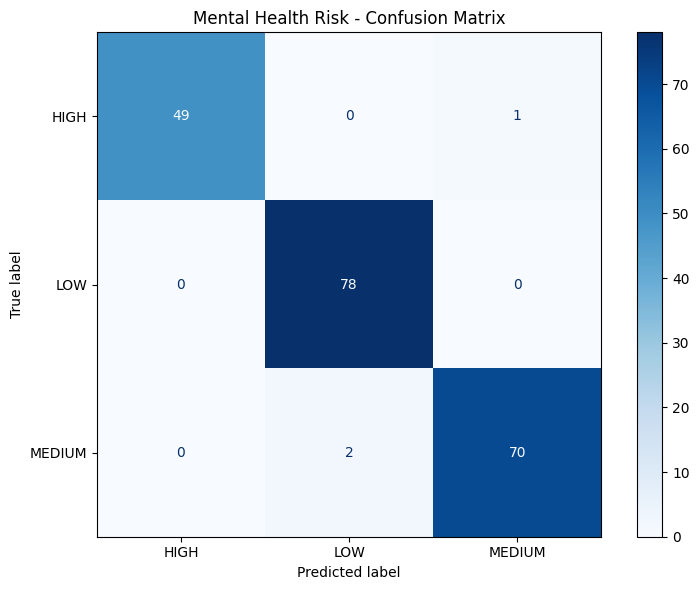

In [15]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Mental Health Risk - Confusion Matrix')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'mental_health_confusion_matrix.png', dpi=150)
plt.show()

## 8. Feature Importance & SHAP Analysis

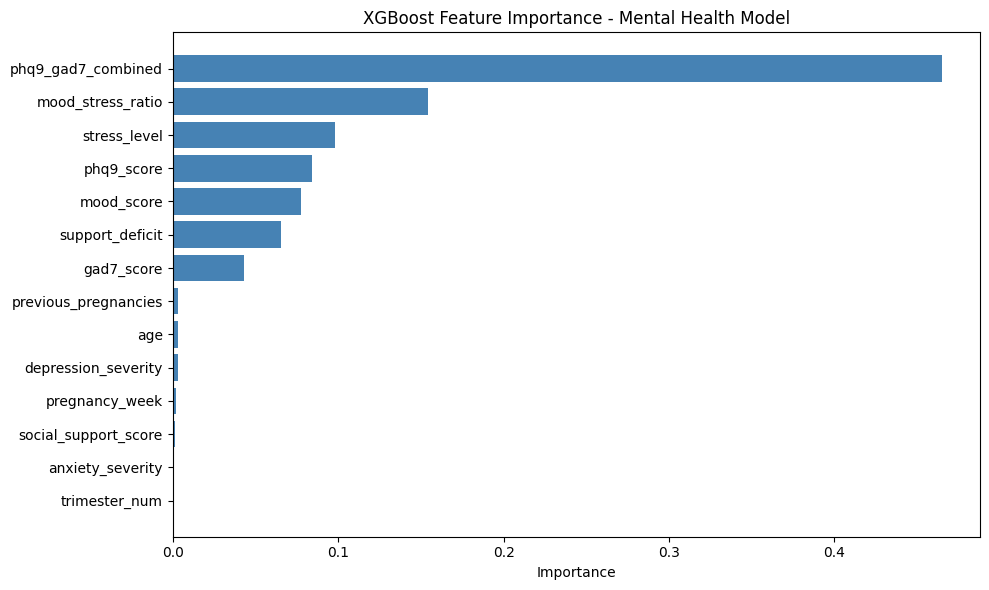

In [16]:
# Feature importance from XGBoost
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance - Mental Health Model')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'mental_health_feature_importance.png', dpi=150)
plt.show()

Computing SHAP values (this may take a moment)...


<Figure size 1000x600 with 0 Axes>

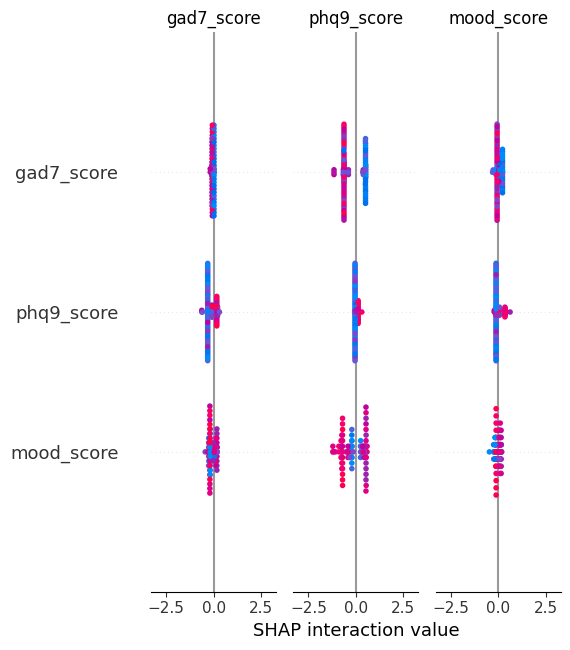

In [17]:
# SHAP values
print("Computing SHAP values (this may take a moment)...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled[:100])  # Use subset for speed

# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled[:100], feature_names=FEATURE_COLS, 
                  class_names=label_encoder.classes_, show=False)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'mental_health_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Model Artifacts

In [18]:
# Save model, scaler, and encoder
joblib.dump(best_model, MODEL_DIR / 'mental_health_xgb.joblib')
joblib.dump(scaler, MODEL_DIR / 'mental_health_scaler.joblib')
joblib.dump(label_encoder, MODEL_DIR / 'mental_health_label_encoder.joblib')

# Save feature columns for inference
with open(MODEL_DIR / 'mental_health_features.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print("✅ Model artifacts saved:")
print(f"   - {MODEL_DIR / 'mental_health_xgb.joblib'}")
print(f"   - {MODEL_DIR / 'mental_health_scaler.joblib'}")
print(f"   - {MODEL_DIR / 'mental_health_label_encoder.joblib'}")
print(f"   - {MODEL_DIR / 'mental_health_features.json'}")

✅ Model artifacts saved:
   - ../../backend/app/ml/models/mental_health_xgb.joblib
   - ../../backend/app/ml/models/mental_health_scaler.joblib
   - ../../backend/app/ml/models/mental_health_label_encoder.joblib
   - ../../backend/app/ml/models/mental_health_features.json


In [19]:
# Save evaluation metrics
metrics = {
    'mental_health': {
        'model': 'XGBoost',
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4),
        'auc_roc': round(auc_roc, 4),
        'best_params': grid_search.best_params_,
        'feature_columns': FEATURE_COLS,
        'dataset': 'Synthetic Mental Health Dataset'
    }
}

# Load existing or create new
metrics_file = REPORT_DIR / 'evaluation_metrics.json'
if metrics_file.exists():
    with open(metrics_file, 'r') as f:
        all_metrics = json.load(f)
    all_metrics.update(metrics)
else:
    all_metrics = metrics

with open(metrics_file, 'w') as f:
    json.dump(all_metrics, f, indent=2)

print(f"\n✅ Metrics saved to {metrics_file}")


✅ Metrics saved to ../reports/evaluation_metrics.json


## 10. Model Inference Test

In [20]:
# Test inference
def predict_mental_risk(phq9, gad7, mood, stress, social_support, age=30, pregnancy_week=20, 
                        trimester=2, previous_pregnancies=0):
    """Predict mental health risk from input features."""
    # Load artifacts
    model = joblib.load(MODEL_DIR / 'mental_health_xgb.joblib')
    scaler = joblib.load(MODEL_DIR / 'mental_health_scaler.joblib')
    encoder = joblib.load(MODEL_DIR / 'mental_health_label_encoder.joblib')
    
    # Engineered features
    phq9_gad7_combined = phq9 + gad7
    mood_stress_ratio = mood / (stress + 1)
    support_deficit = 5 - social_support
    depression_severity = min(4, phq9 // 5)  # Simplified severity
    anxiety_severity = min(3, gad7 // 5)
    
    features = np.array([[
        phq9, gad7, mood, stress, social_support,
        phq9_gad7_combined, mood_stress_ratio, support_deficit,
        depression_severity, anxiety_severity,
        age, pregnancy_week, trimester, previous_pregnancies
    ]])
    
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled)[0]
    probabilities = model.predict_proba(features_scaled)[0]
    
    risk_label = encoder.inverse_transform([prediction])[0]
    confidence = probabilities[prediction]
    
    return {
        'risk_level': risk_label,
        'confidence': round(confidence, 3),
        'probabilities': {
            cls: round(prob, 3) 
            for cls, prob in zip(encoder.classes_, probabilities)
        }
    }

# Test cases
print("\n" + "=" * 50)
print("INFERENCE TEST")
print("=" * 50)

# Low risk profile
result = predict_mental_risk(phq9=3, gad7=2, mood=8, stress=2, social_support=5)
print(f"\nLow Risk Input: PHQ9=3, GAD7=2, Mood=8, Stress=2, Support=5")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")

# Medium risk profile
result = predict_mental_risk(phq9=12, gad7=10, mood=5, stress=6, social_support=3)
print(f"\nMedium Risk Input: PHQ9=12, GAD7=10, Mood=5, Stress=6, Support=3")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")

# High risk profile
result = predict_mental_risk(phq9=22, gad7=18, mood=2, stress=9, social_support=1)
print(f"\nHigh Risk Input: PHQ9=22, GAD7=18, Mood=2, Stress=9, Support=1")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")


INFERENCE TEST

Low Risk Input: PHQ9=3, GAD7=2, Mood=8, Stress=2, Support=5
  → Prediction: LOW (confidence: 0.9990000128746033)

Medium Risk Input: PHQ9=12, GAD7=10, Mood=5, Stress=6, Support=3
  → Prediction: MEDIUM (confidence: 1.0)

High Risk Input: PHQ9=22, GAD7=18, Mood=2, Stress=9, Support=1
  → Prediction: HIGH (confidence: 0.9990000128746033)


---

## Summary

✅ **Mental Health Risk Model trained successfully!**

| Metric | Value |
|--------|-------|
| Algorithm | XGBoost |
| Features | 14 (including engineered) |
| Target | LOW / MEDIUM / HIGH |

### Model Artifacts Saved
- `mental_health_xgb.joblib` — Trained XGBoost model
- `mental_health_scaler.joblib` — StandardScaler for feature normalization
- `mental_health_label_encoder.joblib` — LabelEncoder for risk labels

---

⚠️ **Disclaimer**: This model predicts risk likelihood only — NOT a medical diagnosis. Always consult healthcare professionals.